In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

print("Libraries loaded succcessfully")

Libraries loaded succcessfully


In [2]:
import os
print(os.listdir())

['latam_export_analysis.ipynb', '.ipynb_checkpoints']


In [3]:
# Load csv files
df_lpi = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/data:world_bank_lpi_latam_caribbean.csv')
df_trade = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/TradeData_3_24_2026_14_26_5.csv')

print("LPI Dataset:", df_lpi.columns.tolist())
print("Trade Dataset:", df_trade.columns.tolist())

LPI Dataset: ['Country Name', 'Country Code', 'Series Name', 'Series Code', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']
Trade Dataset: ['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO', 'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification', 'cmdCode', 'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']


In [4]:
# Preview LPI
print(df_lpi.head())

          Country Name Country Code  \
0  Trinidad and Tobago          TTO   
1  Trinidad and Tobago          TTO   
2  Trinidad and Tobago          TTO   
3  Trinidad and Tobago          TTO   
4  Trinidad and Tobago          TTO   

                                         Series Name     Series Code  \
0  Logistics performance index: Ability to track ...  LP.LPI.TRAC.XQ   
1  Logistics performance index: Competence and qu...  LP.LPI.LOGS.XQ   
2  Logistics performance index: Ease of arranging...  LP.LPI.ITRN.XQ   
3  Logistics performance index: Efficiency of cus...  LP.LPI.CUST.XQ   
4  Logistics performance index: Frequency with wh...  LP.LPI.TIME.XQ   

  2014 [YR2014] 2015 [YR2015] 2016 [YR2016] 2017 [YR2017] 2018 [YR2018]  \
0            ..            ..      2.279914            ..          2.27   
1            ..            ..      2.283842            ..          2.27   
2            ..            ..      2.308907            ..          2.59   
3            ..            ..   

In [5]:
# Cleaning column names with pattern
df_lpi.columns = df_lpi.columns.str.replace(r' \[YR\d+\]', '', regex=True)

# Check
print(df_lpi.head())

          Country Name Country Code  \
0  Trinidad and Tobago          TTO   
1  Trinidad and Tobago          TTO   
2  Trinidad and Tobago          TTO   
3  Trinidad and Tobago          TTO   
4  Trinidad and Tobago          TTO   

                                         Series Name     Series Code 2014  \
0  Logistics performance index: Ability to track ...  LP.LPI.TRAC.XQ   ..   
1  Logistics performance index: Competence and qu...  LP.LPI.LOGS.XQ   ..   
2  Logistics performance index: Ease of arranging...  LP.LPI.ITRN.XQ   ..   
3  Logistics performance index: Efficiency of cus...  LP.LPI.CUST.XQ   ..   
4  Logistics performance index: Frequency with wh...  LP.LPI.TIME.XQ   ..   

  2015      2016 2017  2018 2019 2020 2021 2022 2023  
0   ..  2.279914   ..  2.27   ..   ..   ..  2.5   ..  
1   ..  2.283842   ..  2.27   ..   ..   ..  2.4   ..  
2   ..  2.308907   ..  2.59   ..   ..   ..  2.5   ..  
3   ..  2.377717   ..  2.42   ..   ..   ..  2.2   ..  
4   ..  2.788676   ..  2.53

In [6]:
# Reshape Data- Melt
df_lpi_melted = df_lpi.melt(
    id_vars = ['Country Name', 'Country Code', 'Series Name'],
    value_vars = ['2016', '2018', '2020', '2022'],
    var_name = 'year',
    value_name = 'score'
)

# Check
print(df_lpi_melted.head())
print(df_lpi_melted.columns.tolist())

          Country Name Country Code  \
0  Trinidad and Tobago          TTO   
1  Trinidad and Tobago          TTO   
2  Trinidad and Tobago          TTO   
3  Trinidad and Tobago          TTO   
4  Trinidad and Tobago          TTO   

                                         Series Name  year     score  
0  Logistics performance index: Ability to track ...  2016  2.279914  
1  Logistics performance index: Competence and qu...  2016  2.283842  
2  Logistics performance index: Ease of arranging...  2016  2.308907  
3  Logistics performance index: Efficiency of cus...  2016  2.377717  
4  Logistics performance index: Frequency with wh...  2016  2.788676  
['Country Name', 'Country Code', 'Series Name', 'year', 'score']


In [7]:
# Convert score to numeric first
df_lpi_melted['score'] = pd.to_numeric(df_lpi_melted['score'], errors='coerce')

# Reshape data- Pivot table
df_lpi_pivot = df_lpi_melted.pivot_table(
    index = ['Country Name', 'Country Code', 'year'],
    columns = 'Series Name',
    values = 'score',
).reset_index()

print(df_lpi_pivot.head())

Series Name         Country Name Country Code  year  \
0            Antigua and Barbuda          ATG  2022   
1                      Argentina          ARG  2022   
2                      Argentina          ARG  2016   
3                      Argentina          ARG  2018   
4                   Bahamas, The          BHS  2022   

Series Name  Logistics performance index: Ability to track and trace consignments (1=low to 5=high)  \
0                                                     3.200000                                        
1                                                     2.900000                                        
2                                                     3.260731                                        
3                                                     3.050000                                        
4                                                     2.600000                                        

Series Name  Logistics performance index: Competen

In [8]:
# Rename all columns at once
df_lpi_pivot.columns = ['Country Name', 'Country Code', 'Year', 'Tracking', 'Competence', 'Shipments', 'Customs', 'Frequency', 'Overall', 'Quality & Infrastructure']

# Check
print(df_lpi_pivot.head())

          Country Name Country Code  Year  Tracking  Competence  Shipments  \
0  Antigua and Barbuda          ATG  2022  3.200000    2.900000   2.900000   
1            Argentina          ARG  2022  2.900000    2.700000   2.700000   
2            Argentina          ARG  2016  3.260731    2.825233   2.759638   
3            Argentina          ARG  2018  3.050000    2.780000   2.920000   
4         Bahamas, The          BHS  2022  2.600000    2.500000   3.100000   

    Customs  Frequency   Overall  Quality & Infrastructure  
0  2.200000   3.400000  2.900000                  2.700000  
1  2.700000   3.100000  2.800000                  2.800000  
2  2.628572   3.470985  2.962629                  2.856412  
3  2.420000   3.370000  2.890000                  2.770000  
4  2.700000   3.000000  2.700000                  2.500000  


In [9]:
# Clean trade dataset
print(df_trade.head())

  typeCode  freqCode  refPeriodId  refYear  refMonth  period reporterCode  \
C        A  20180101         2018       52      2018      32          ARG   
C        A  20180101         2018       52      2018      76          BRA   
C        A  20180101         2018       52      2018     152          CHL   
C        A  20180101         2018       52      2018     170          COL   
C        A  20180101         2018       52      2018     214          DOM   

      reporterISO reporterDesc flowCode  ...  netWgt isNetWgtEstimated  \
C       Argentina            X   Export  ...   False               0.0   
C          Brazil            X   Export  ...    True               0.0   
C           Chile            X   Export  ...    True               0.0   
C        Colombia            X   Export  ...    True               NaN   
C  Dominican Rep.            X   Export  ...   False               0.0   

  grossWgt  isGrossWgtEstimated      cifvalue      fobvalue primaryValue  \
C    False      

In [10]:
# Selecting only the columns needed
df_trade_clean = df_trade[['refPeriodId', 'reporterCode', 'reporterISO', 'fobvalue']].copy()

# Check
print(df_trade_clean.head())

   refPeriodId reporterCode     reporterISO      fobvalue
C         2018          ARG       Argentina  6.155941e+10
C         2018          BRA          Brazil  2.318895e+11
C         2018          CHL           Chile  7.483798e+10
C         2018          COL        Colombia  4.183152e+10
C         2018          DOM  Dominican Rep.  1.075801e+10


In [11]:
# Rename all columns
df_trade_clean.columns = ['Year', 'Country Code', 'Country Name', 'Export Value USD']

# Check
print(df_trade_clean.head())

   Year Country Code    Country Name  Export Value USD
C  2018          ARG       Argentina      6.155941e+10
C  2018          BRA          Brazil      2.318895e+11
C  2018          CHL           Chile      7.483798e+10
C  2018          COL        Colombia      4.183152e+10
C  2018          DOM  Dominican Rep.      1.075801e+10


In [12]:
# Renaming Dominican Rep.
df_trade_clean['Country Name'] = df_trade_clean['Country Name'].str.replace('Dominican Rep.', 'Dominican Republic')

# Check
print(df_trade_clean.head())

   Year Country Code        Country Name  Export Value USD
C  2018          ARG           Argentina      6.155941e+10
C  2018          BRA              Brazil      2.318895e+11
C  2018          CHL               Chile      7.483798e+10
C  2018          COL            Colombia      4.183152e+10
C  2018          DOM  Dominican Republic      1.075801e+10


In [13]:
# Check data types
print(df_lpi_pivot.info())
print(df_trade_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country Name              69 non-null     object 
 1   Country Code              69 non-null     object 
 2   Year                      69 non-null     object 
 3   Tracking                  69 non-null     float64
 4   Competence                69 non-null     float64
 5   Shipments                 69 non-null     float64
 6   Customs                   69 non-null     float64
 7   Frequency                 69 non-null     float64
 8   Overall                   69 non-null     float64
 9   Quality & Infrastructure  69 non-null     float64
dtypes: float64(7), object(3)
memory usage: 5.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, C to C
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------

In [14]:
# Change Year ti an integer
df_lpi_pivot['Year'] = df_lpi_pivot['Year'].astype(int)

# Filter years that match both datasets
df_lpi_filtered = df_lpi_pivot[df_lpi_pivot['Year'].isin([2018, 2022])].copy()
df_trade_filtered = df_trade_clean[df_trade_clean['Year'].isin([2018, 2022])].copy()

In [15]:
# Now merge both datasets
df_merged = pd.merge(
    df_trade_filtered,
    df_lpi_filtered,
    on=['Country Name', 'Country Code', 'Year'],
    how='inner'
)

print("Shape:", df_merged.shape)
print(df_merged.head())

Shape: (18, 11)
   Year Country Code        Country Name  Export Value USD  Tracking  \
0  2018          ARG           Argentina      6.155941e+10      3.05   
1  2018          BRA              Brazil      2.318895e+11      3.11   
2  2018          CHL               Chile      7.483798e+10      3.20   
3  2018          COL            Colombia      4.183152e+10      3.08   
4  2018          DOM  Dominican Republic      1.075801e+10      2.97   

   Competence  Shipments  Customs  Frequency  Overall  \
0        2.78       2.92     2.42       3.37     2.89   
1        3.09       2.88     2.41       3.51     2.99   
2        3.13       3.27     3.27       3.80     3.32   
3        2.87       3.19     2.61       3.17     2.94   
4        2.44       2.77     2.41       2.98     2.66   

   Quality & Infrastructure  
0                      2.77  
1                      2.93  
2                      3.21  
3                      2.67  
4                      2.36  


In [16]:
import math

# Haversine function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    return R * c

# Panama Canal coordinates
PANAMA_LAT = 9.08
PANAMA_LON = -79.68

# Country coordinates
country_coords = {
    'Argentina':           (-34.6037, -58.3816),
    'Brazil':              (-23.5505, -46.6333),
    'Chile':               (-33.4489, -70.6693),
    'Colombia':            (10.3910,  -75.4794),
    'Dominican Republic':  (18.4861,  -69.9312),
    'Jamaica':             (17.9970,  -76.7936),
    'Mexico':              (19.4326,  -99.1332),
    'Panama':              (8.9936,   -79.5197),
    'Peru':                (-12.0464, -77.0428),
}

# Calculate distances
results = []
for country, (lat, lon) in country_coords.items():
    dist = haversine(PANAMA_LAT, PANAMA_LON, lat, lon)
    results.append({'Country Name': country, 'distance_to_canal_km': round(dist)})

df_distances = pd.DataFrame(results)

# Merge into main dataset
df_merged = pd.merge(df_merged, df_distances, on='Country Name', how='left')

print(df_merged.shape)
print(df_merged[['Country Name', 'Year', 'distance_to_canal_km', 'Overall']].head(9))

(18, 12)
         Country Name  Year  distance_to_canal_km  Overall
0           Argentina  2018                  5350     2.89
1              Brazil  2018                  5106     2.99
2               Chile  2018                  4824     3.32
3            Colombia  2018                   483     2.94
4  Dominican Republic  2018                  1483     2.66
5             Jamaica  2018                  1039     2.52
6              Mexico  2018                  2388     3.05
7              Panama  2018                    20     3.28
8                Peru  2018                  2367     2.69


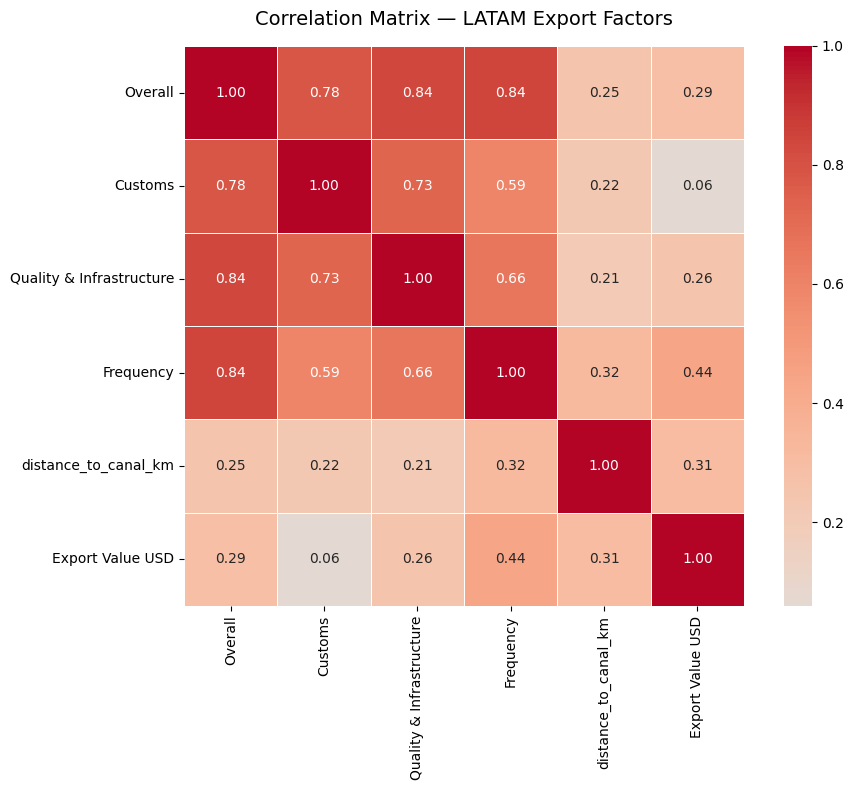

Chart 1 saved!


In [17]:
# Chart 1- correlation heatmap

# Select variables for correlation
correlation_vars = ['Overall', 'Customs', 'Quality & Infrastructure', 
                    'Frequency', 'distance_to_canal_km', 'Export Value USD']

corr_matrix = df_merged[correlation_vars].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix — LATAM Export Factors', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('/Users/ashantimiller/latam-export-analysis/visuals/correlation_heatmap.png', dpi=150)
plt.show()

print("Chart 1 saved!")

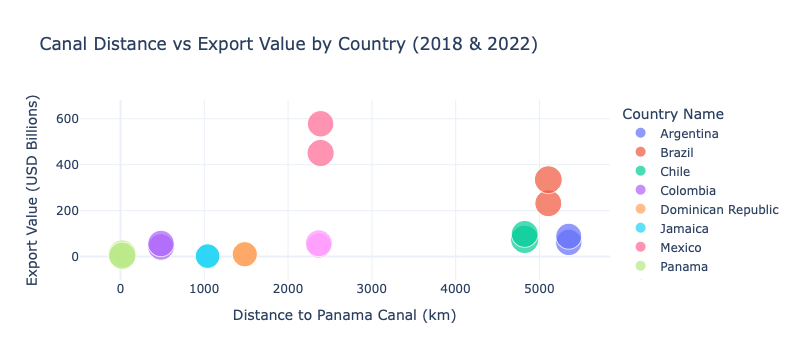

Chart 2 saved!


In [18]:
# Chart 2- Scatter plot 

# Convert export value to billions
df_merged['Export Billions'] = df_merged['Export Value USD'] / 1e9

# Scatter plot
fig = px.scatter(
    df_merged,
    x='distance_to_canal_km',
    y='Export Billions',
    color='Country Name',
    size='Overall',
    hover_name='Country Name',
    hover_data=['Year', 'Overall', 'Customs'],
    title='Canal Distance vs Export Value by Country (2018 & 2022)',
    labels={
        'distance_to_canal_km': 'Distance to Panama Canal (km)',
        'Export Billions': 'Export Value (USD Billions)',
        'Overall': 'LPI Score'
    },
    template='plotly_white'
)

fig.write_html('/Users/ashantimiller/latam-export-analysis/visuals/scatter_distance_exports.html')
fig.show()
print("Chart 2 saved!")

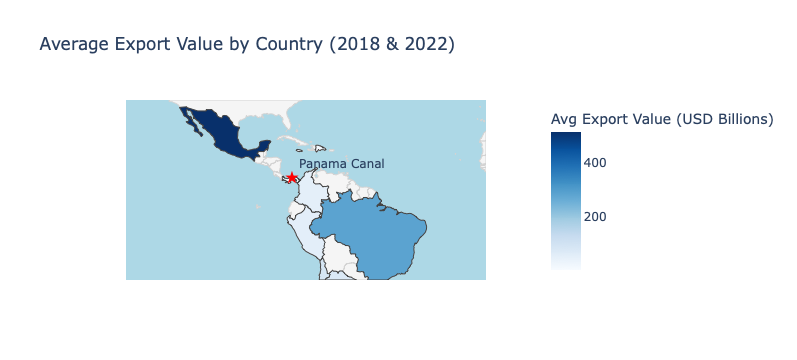

Chart 3 saved!


In [19]:
# Average export value per country
df_map = df_merged.groupby(['Country Name', 'Country Code'])['Export Billions'].mean().reset_index()
df_map.columns = ['country', 'iso_code', 'avg_export_billions']

fig3 = px.choropleth(
    df_map,
    locations='iso_code',
    color='avg_export_billions',
    hover_name='country',
    hover_data={'avg_export_billions': ':.1f', 'iso_code': False},
    color_continuous_scale='Blues',
    title='Average Export Value by Country (2018 & 2022)',
    labels={'avg_export_billions': 'Avg Export Value (USD Billions)'}
)

fig3.update_geos(
    scope='world',
    center={"lat": 5, "lon": -75},
    projection_scale=3,
    visible=False,
    showcountries=True,
    countrycolor='lightgray',
    showland=True,
    landcolor='whitesmoke',
    showocean=True,
    oceancolor='lightblue'
)

# Add Panama Canal marker
fig3.add_scattergeo(
    lat=[9.08],
    lon=[-79.68],
    mode='markers+text',
    marker=dict(size=10, color='red', symbol='star'),
    text=['Panama Canal'],
    textposition='top right',
    name='Panama Canal'
)

fig3.write_html('/Users/ashantimiller/latam-export-analysis/visuals/choropleth_map.html')
fig3.show()
print("Chart 3 saved!")


In [21]:
# Changing file name
df_trade = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/un_comtrade_latam_exports.csv')
